<a href="https://colab.research.google.com/github/markmilner21/Mayco-Glaze-Similarity-Search/blob/main/rough/pipeline/SW_data_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
from google.colab import files

uploaded = files.upload()

Saving SW-106-Alabaster.pdf to SW-106-Alabaster (2).pdf


In [44]:
pip install pymupdf pillow

Page 1 — 1 accepted, 11 rejected


/tmp/ipykernel_8624/405406425.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


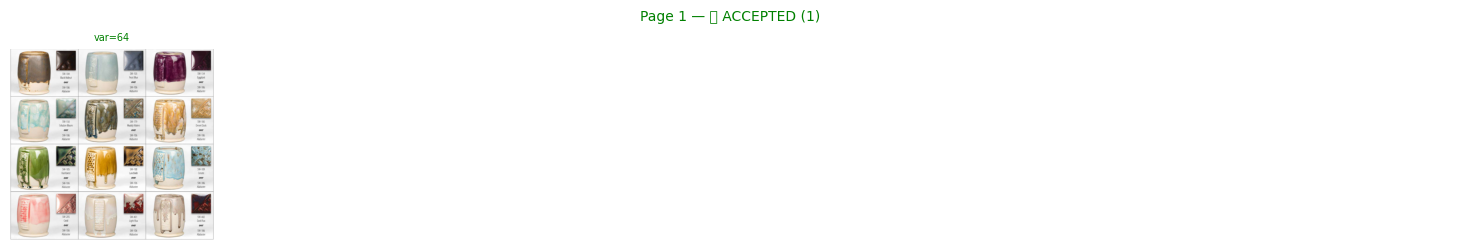

/tmp/ipykernel_8624/405406425.py:100: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


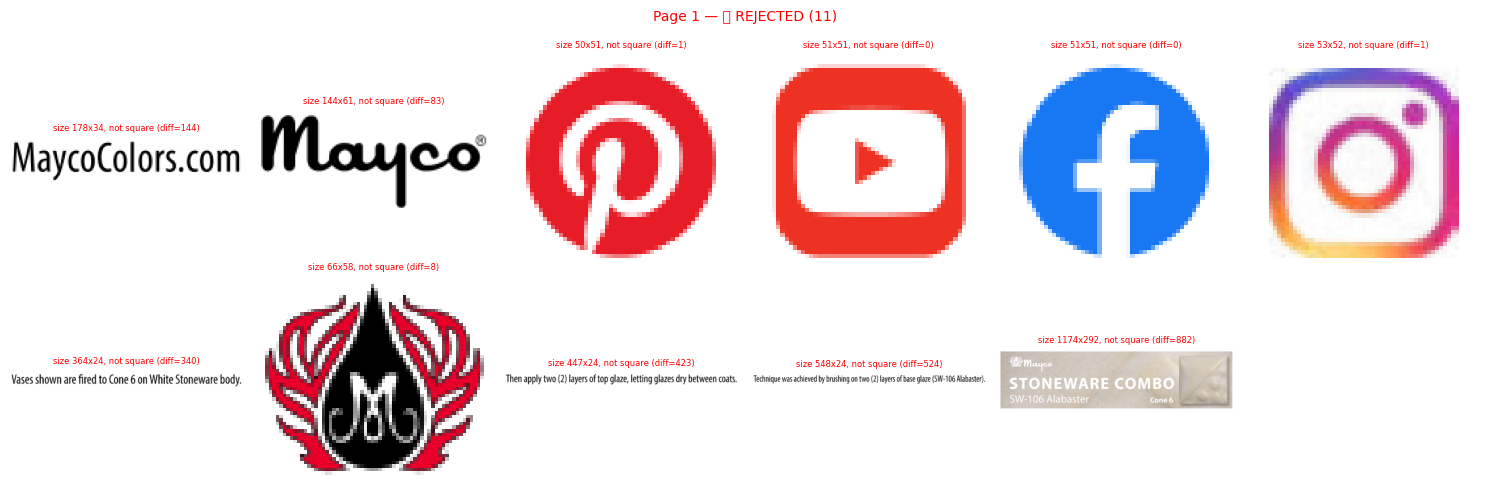

Page 2 — 1 accepted, 12 rejected


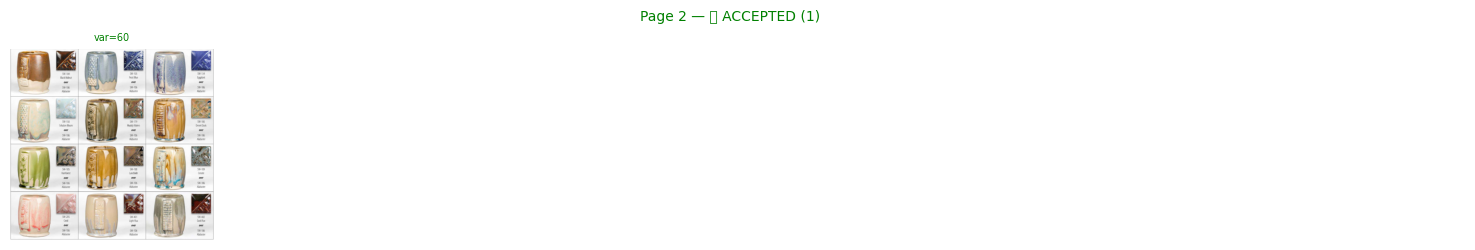

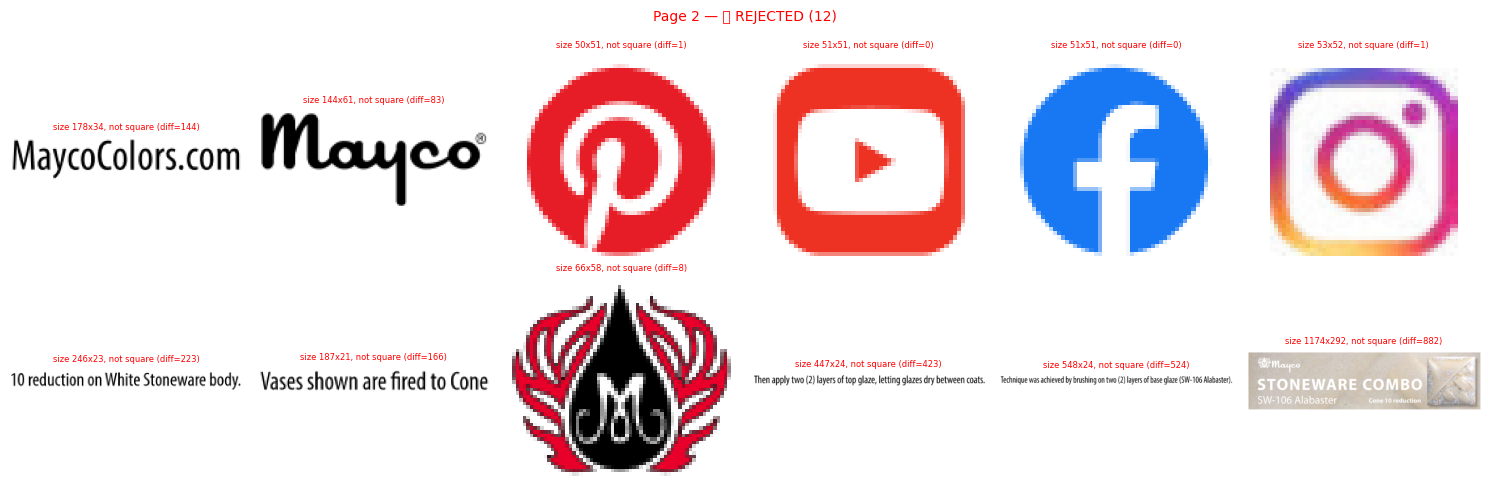

In [48]:
import fitz
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

uploaded_file = list(uploaded.keys())[0]
doc = fitz.open(uploaded_file)

VARIANCE_THRESHOLD = 21
MIN_SIZE = 1100
MAX_SIZE = 1200

def colour_variance(crop):
    return float(np.std(crop.astype(float)))

def overlap(a, b, threshold=0.5):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix = max(0, min(ax+aw, bx+bw) - max(ax, bx))
    iy = max(0, min(ay+ah, by+bh) - max(ay, by))
    inter = ix * iy
    smaller = min(aw * ah, bw * bh)
    return inter / smaller > threshold if smaller > 0 else False

def detect_swatches(img_array):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(blurred, 30, 100)
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    accepted = []
    rejected = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        if w < 20 or h < 20:
            continue

        crop = img_array[y:y+h, x:x+w]
        variance = colour_variance(crop)

        reasons = []
        if not (MIN_SIZE <= w <= MAX_SIZE and MIN_SIZE <= h <= MAX_SIZE):
            reasons.append(f"size {w}x{h}")
        if abs(w - h) != 70: # changed:
            reasons.append(f"not square (diff={abs(w-h)})")
        if variance <= VARIANCE_THRESHOLD:
            reasons.append(f"flat var={variance:.0f}")

        if reasons:
            rejected.append((x, y, w, h, variance, ", ".join(reasons), crop))
        else:
            accepted.append((x, y, w, h, variance))

    filtered = []
    for c in sorted(accepted, key=lambda c: c[2]*c[3], reverse=True):
        if not any(overlap(c[:4], kept[:4]) for kept in filtered):
            filtered.append(c)

    return sorted(filtered, key=lambda c: (c[1], c[0])), rejected

for page_number, page in enumerate(doc, start=1):
    pix = page.get_pixmap(dpi=150)
    img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)

    accepted, rejected = detect_swatches(img_array)
    print(f"Page {page_number} — {len(accepted)} accepted, {len(rejected)} rejected")

    if accepted:
        cols = 6
        rows = -(-len(accepted) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = axes.flatten()
        for i, (x, y, w, h, variance) in enumerate(accepted):
            axes[i].imshow(img_array[y:y+h, x:x+w])
            axes[i].axis("off")
            axes[i].set_title(f"var={variance:.0f}", fontsize=7, color="green")
        for j in range(len(accepted), len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Page {page_number} — ✅ ACCEPTED ({len(accepted)})", fontsize=10, color="green")
        plt.tight_layout()
        plt.show()

    if rejected:
        cols = 6
        rows = -(-len(rejected) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = axes.flatten()
        for i, (x, y, w, h, variance, reason, crop) in enumerate(rejected):
            axes[i].imshow(crop)
            axes[i].axis("off")
            axes[i].set_title(f"{reason}", fontsize=6, color="red")
        for j in range(len(rejected), len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Page {page_number} — ❌ REJECTED ({len(rejected)})", fontsize=10, color="red")
        plt.tight_layout()
        plt.show()

this processing won't work. you can see the entire grid of glazes is getting picked up as one swatch.

Solution 1 — Grid-based slicing (BEST)

Instead of finding contours, just split the image into tiles.

doesn't seem to be working sadly. Let's try using the fact that it's a 4 row x 3 column grid

Saving Screenshot 2026-03-31 213013.png to Screenshot 2026-03-31 213013 (10).png
81
115


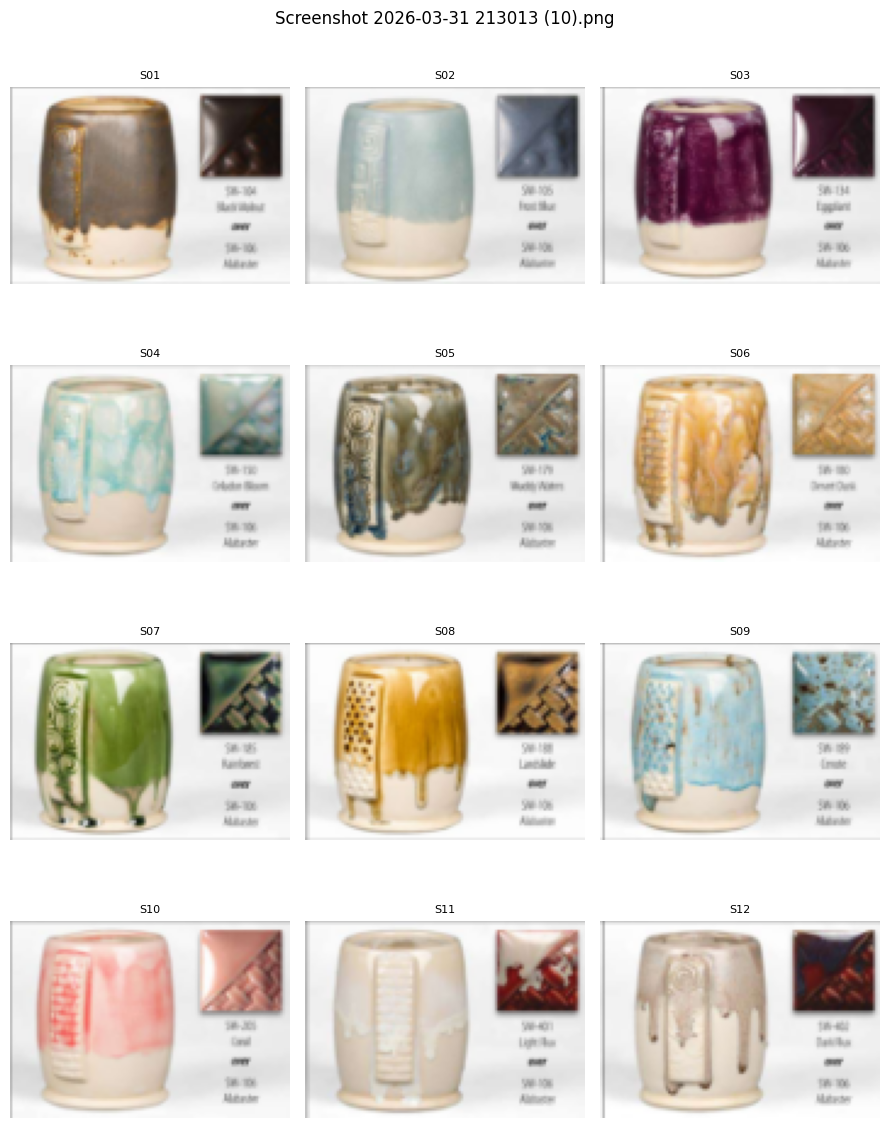

Saved 12 swatches from Screenshot 2026-03-31 213013 (10).png


In [39]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io

# ================================
# CONFIG — change these
# ================================
GRID_ROWS = 4
GRID_COLS = 3

# ================================
# UPLOAD & SPLIT
# ================================
uploaded = files.upload()

for filename, data in uploaded.items():
    img = Image.open(io.BytesIO(data))
    img_array = np.array(img)
    h, w = img_array.shape[:2]

    cell_h = h // GRID_ROWS
    cell_w = w // GRID_COLS
    print(cell_h)
    print(cell_w)

    fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(GRID_COLS * 3, GRID_ROWS * 3))

    for row in range(GRID_ROWS):
        for col in range(GRID_COLS):
            y1, y2 = row * cell_h, (row + 1) * cell_h
            x1, x2 = col * cell_w, (col + 1) * cell_w

            swatch = img_array[y1:y2, x1:x2]
            num = row * GRID_COLS + col + 1

            Image.fromarray(swatch).save(f"swatch_{num:02d}.png")

            axes[row, col].imshow(swatch)
            axes[row, col].set_title(f"S{num:02d}", fontsize=8)
            axes[row, col].axis("off")

    plt.suptitle(filename)
    plt.tight_layout()
    plt.show()
    print(f"Saved {GRID_ROWS * GRID_COLS} swatches from {filename}")

In [40]:
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-03-31 214450.png to Screenshot 2026-03-31 214450.png


Page 1 — 1 accepted, 3 rejected


/tmp/ipykernel_8624/1410878400.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


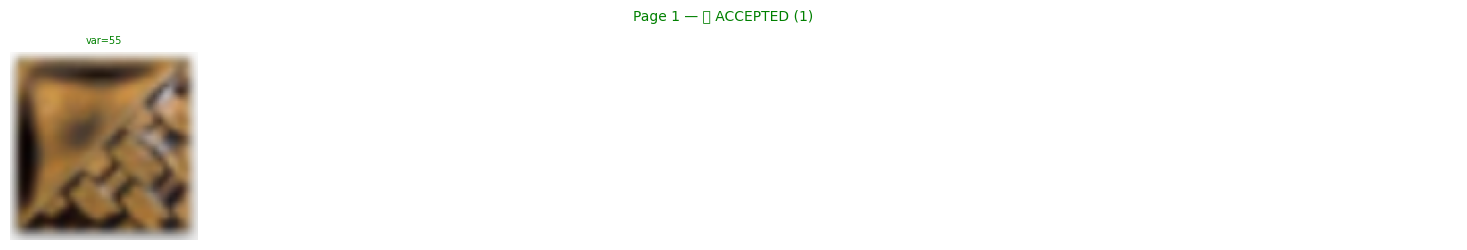

/tmp/ipykernel_8624/1410878400.py:100: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


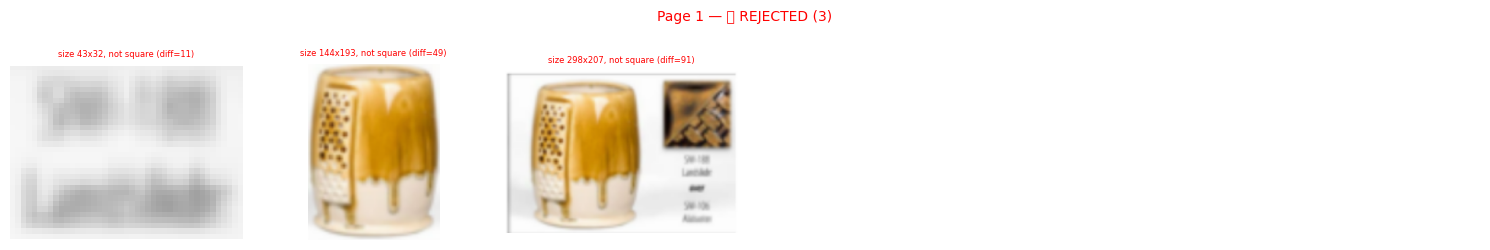

In [42]:
import fitz
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

uploaded_file = list(uploaded.keys())[0]
doc = fitz.open(uploaded_file)

VARIANCE_THRESHOLD = 21
MIN_SIZE = 90
MAX_SIZE = 100

def colour_variance(crop):
    return float(np.std(crop.astype(float)))

def overlap(a, b, threshold=0.5):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix = max(0, min(ax+aw, bx+bw) - max(ax, bx))
    iy = max(0, min(ay+ah, by+bh) - max(ay, by))
    inter = ix * iy
    smaller = min(aw * ah, bw * bh)
    return inter / smaller > threshold if smaller > 0 else False

def detect_swatches(img_array):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    edges = cv2.Canny(blurred, 30, 100)
    kernel = np.ones((3, 3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=2)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    accepted = []
    rejected = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        if w < 20 or h < 20:
            continue

        crop = img_array[y:y+h, x:x+w]
        variance = colour_variance(crop)

        reasons = []
        if not (MIN_SIZE <= w <= MAX_SIZE and MIN_SIZE <= h <= MAX_SIZE):
            reasons.append(f"size {w}x{h}")
        if abs(w - h) > 3:
            reasons.append(f"not square (diff={abs(w-h)})")
        if variance <= VARIANCE_THRESHOLD:
            reasons.append(f"flat var={variance:.0f}")

        if reasons:
            rejected.append((x, y, w, h, variance, ", ".join(reasons), crop))
        else:
            accepted.append((x, y, w, h, variance))

    filtered = []
    for c in sorted(accepted, key=lambda c: c[2]*c[3], reverse=True):
        if not any(overlap(c[:4], kept[:4]) for kept in filtered):
            filtered.append(c)

    return sorted(filtered, key=lambda c: (c[1], c[0])), rejected

for page_number, page in enumerate(doc, start=1):
    pix = page.get_pixmap(dpi=150)
    img_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)

    accepted, rejected = detect_swatches(img_array)
    print(f"Page {page_number} — {len(accepted)} accepted, {len(rejected)} rejected")

    if accepted:
        cols = 6
        rows = -(-len(accepted) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = axes.flatten()
        for i, (x, y, w, h, variance) in enumerate(accepted):
            axes[i].imshow(img_array[y:y+h, x:x+w])
            axes[i].axis("off")
            axes[i].set_title(f"var={variance:.0f}", fontsize=7, color="green")
        for j in range(len(accepted), len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Page {page_number} — ✅ ACCEPTED ({len(accepted)})", fontsize=10, color="green")
        plt.tight_layout()
        plt.show()

    if rejected:
        cols = 6
        rows = -(-len(rejected) // cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = axes.flatten()
        for i, (x, y, w, h, variance, reason, crop) in enumerate(rejected):
            axes[i].imshow(crop)
            axes[i].axis("off")
            axes[i].set_title(f"{reason}", fontsize=6, color="red")
        for j in range(len(rejected), len(axes)):
            axes[j].axis("off")
        plt.suptitle(f"Page {page_number} — ❌ REJECTED ({len(rejected)})", fontsize=10, color="red")
        plt.tight_layout()
        plt.show()

it looks like we finally have the swatch so maybe this will work. this requires you to essentially do the same processing, obtain the grid, from that grid, crop each grid element and then run the swatching again

its not ideal and it's less automation and more manual involvement but it's not awful